# Introduction

This guide explains how to use the `decentralized market software` and in doing so explains the economics behind the software.  

## A Brief Overview
Here is a very brief description that will be explained in more detail later in this guide.

### Agent Types
* There are **num_traders** agents who are either a `BUYER` or a `SELLER`. In the baseline case, there is an equal number of buyers and sellers.
* Agent behavior is dictated by their strategic type.

> Presently, you can choose from the following agent types:
* `ZID`: Basic zero intelligence trader. Makes and accepts bids/asks randomly within its budget and moves randomly in every period. See Gode and Sunder 1993.
* `ZIDP`: Extend ZID - but accepts only the most favorable bid/ask available.
* `ZIDA`: Extend ZID - but uses a rule-of-thumb movement rule which lead to staying at locations if an agent traded recently. The default rule of thumb is for an agent to stay at a location if they have traded at least $num\_ trades$ times in the last $window\_ size$ periods, with $num \_ trades = 1$ and $window\_ size = num\_ periods$ (the length of one week).
* `ZIDPA`: Extend ZIDP - but implement the ZIDA sticky movement rule.
* `ZIDPR`: Extend ZIDPA - but implement an additional rule which prevents staying at a location if there are more than two agents at this location.
* `ZIDT`: (InDev) Extend ZID - but implement a movement rule which attempts to maximize observed payoffs. An agent will start with no earnings expectations, but will build and maintain a memory of their earnings, $p_j$ for the $2\eta$ most recent periods. Agents will form an earnings expectation, $\bar{p_{\eta}} = \frac{1}{\eta} \sum_{j=0}^{\eta}p_j$ after experiencing their first $\eta$ periods, and continuously update this expectation to reflect the most recent $p_j \forall j \in \{-2\eta, \ldots, -\eta\}$, such that $\bar{p_{\eta}} = \frac{1}{\eta} \sum_{j=-2\eta}^{-\eta}p_j$ once these periods have been observed. Agents stay at their current location if they earn at least $\bar{p_{\eta}}-\nu\sigma(p_{\eta})$ on average in the most recent $\eta$ periods. $\sigma(\bar{p_{\eta}})$ is the standard deviation of $p_j \forall j \in {-2\eta, \ldots, -\eta}$ and $\nu$ is a risk-aversion (or equivalently patience) parameter.
* `ZIDTR`: (InDev) Extend ZIDT - but implement an additional rule which prevents staying at a location if there are more than two agents at this location.
* Note agents behave according to their base rules (ZID) if none of their additional conditions are triggered (e.g. if the ZIDA rule of thumb is not triggered, it behaves as if it were a ZID agent).

### Demand
* Buyers have **num_units** random reservation values for units they buy.
* Each value is randomly drawn, s.t. $v \in U[lower\_ bound, upper \_ bound]$ and then sorted from high to low.
* In the baseline case, buyers have ex ante homogenous valuations.
* This demand schedule is fixed, resetting to the same values at the start of each week.
* `Aggregate Demand` is the list of all buyers' reservation values sorted from highest to lowest.
* BUYERs earn a payoff for each successfully traded unit of $p_i = v_i-t_i$, where $t_i$ is the unit trade price and $v_i$ is their reservation value on the unit.

### Supply
* Sellers have **num_units** unit costs for units they sell.
* Each cost is randomly drawn, s.t. $c \in U[lower\_ bound, upper\_ bound]$ and then sorted from low to high
* In the baseline case, sellers have ex ante homogenous valuations.
* `Aggregate Supply` is the list of all sellers' unit_costs sorted from lowest to highest.
* SELLERs earn a payoff for each successfully traded unit of $p_i = t_i-c_i$, where $t_i$ is the unit trade price and $c_i$ is their reservation cost on the unit.

### Time Segments and Nesting
* There are **num_periods** in a week and **num_weeks** in a simulation trial. 
* Each period agents can move and subsequently trade.
* At the start of each week, agents' reservations values/costs are renewed.
* There are **num_trials** in a Monte Carlo of simulations.
* Trials are independent.

### Spacial Grid and Movement
* Agents start randomly allocated on a square grid of **grid_size** x **grid_size** nodes.
* Agents can travel to an adjacent location (up to 8 directions) on the grid at the beginning of each period.
* Agents cannot travel across grid boundaries (the grid is bounded).
* In addition to obeying the movement rules prescribed by their strategic type, agents have a flat movement error rate $m \in [0, 1]$ which overrides their movement rule with random movement choices instead, with a probability of $P(random\_ move)=m$.

### Agent Trading
> Agents at the same location after moving each period can negotiate a contract:
* Contracts are for one unit
* A contract is made between a buyer and seller and is an agreement to a price. `contract =  (buyer_id, seller_id, price)`
* When a contract is made the `buyer earns: value - price`, and the `seller earns price - cost`

> Each period negotiation occurs after agents have moved
* Negotiation lasts **num_rounds**
* each round consists of a `order stage` and a `transact stage`
* in the `order stage` buyers make `BIDS` and sellers make `ASKS` which are put in an `order_book`.
* in the `transact stage` buyers send `BUY` messages and sellers send `SELL` messages to the `order book`.
* valid `BUY` and `SELL` messages result in contracts

### Performance and Efficiency
> To measure the performance of a market we calculate efficiency as actual_earnings/maximum_earnings
* actual_earnings is the sum of buyer and seller earnings as calculated from contracts
* maximum earnings is the area between supply and demand up to the competitive equilibrium

### Visualizations
> Visualization of Demand and Supply

> Visualization of Performance

> Visualization of Movement

### Conducting Experiments with the Simulation
> Setting up an Experiment

> Conducting statistical tests

## Configuration and Imports

In [1]:
import os
import sys

# Data processing
import numpy as np                              # import numpy
import pandas as pd

# Plotting
import matplotlib.pyplot as plt                 # import matplotlib

# Custom packages for simulation
# This works only if notebooks folder is in the "modules" parent folder
sys.path.insert(0, '..') # add modules folder (parent folder) into this notebook's path

# Institution modules
import institutions.dm_bargain as dm_bargain
import institutions.dm_travel as dm_travel

# Environment modules
import environment.dm_agents as dm_agents
import environment.dm_env as env
import environment.env_make_agents as env_make_agents

# Simulation modules
import simulations.dm_sim_period as simulate
import simulations.dm_sim as dm_sim

# Import functions to run experiments
import simulations.dm_sim_experiment as dm_sim_experiment

# Utility modules
import utils.dm_utils as dm_utils
import utils.dm_process_results as dm_process_results
import utils.dm_res_helpers as dm_res_helpers # Extended results module
import utils.dm_stats as dm_stat

# Import notebook helper functions
import utils.nb_helpers as nb_helpers

# Stats models
from scipy.stats import sem

## Run a Baseline Simulation Monte-Carlo

In [2]:
sim_name = "ZID MONTE-CARLO" # Name your simulation
num_trials = 10 # Choose the number of trials
num_weeks = 50 # Choose the number of weeks
num_periods = 7 # Choose the number of periods in week
num_rounds = 5 # Choose the number of trading rounds within a period
grid_size = 15 # Choose the grid size
num_traders = 10 # Define the number of traders - used as a verification to check agent group definition

# Define trader groups - These are the traders which will go into your simulation
group_size = int(num_traders/2) # Note: The group size (number of agents in a group) must be an integer
lower_bound = 200 # Lower bound on 
upper_bound = 600
num_units = 8 # Number of units each trader demands/supplies
# starting endowments
buy_endow = 500
sell_endow = 0
move_error_rate = 0 # chance to randomly move and override movement strategy
starting_location = None # Location each agent starts at; None = randomly on grid
agent_class = 'ZID' # String name of the agent class
strategy_params = None # Parameters required for the strategy - ZIDA and ZIDT types require inputs

buy_group = [group_size, 'BUYER', agent_class, strategy_params, lower_bound, upper_bound, num_units, buy_endow, 'utility', move_error_rate, starting_location]

sell_group = [group_size, 'SELLER', agent_class, strategy_params, lower_bound, upper_bound, num_units, sell_endow, 'profit', move_error_rate, starting_location]

agent_groups = [buy_group, sell_group]

# run Monte_Carlo
sim_data = dm_sim.make_monte_carlo(sim_name, 
                                        num_trials, num_weeks, num_periods, num_rounds,
                                        num_traders, agent_groups, grid_size=grid_size)
print(sim_name, 'finished.')

ZID MONTE-CARLO finished.


## Collect Efficiency Measure

**eff_avg\[week\]** is the average efficiency over all trials for that week

**std_error\[week\]** is the standard error of the average

In [3]:
eff_avg, std_error, eff_min, eff_max = dm_sim.analyze_eff_data(num_trials, num_weeks, sim_data)
print('Efficiency measures collected')

Efficiency measures collected


## Graph efficiency measures

For simplicity, use the dm_utils.draw_efficiency(\*) helper function to graph simple efficiencies. This function takes a sim_data object, returned by sim_utils.make_monte_carlo(\*) or a list of these objects, as well as a custom title and custom labels.

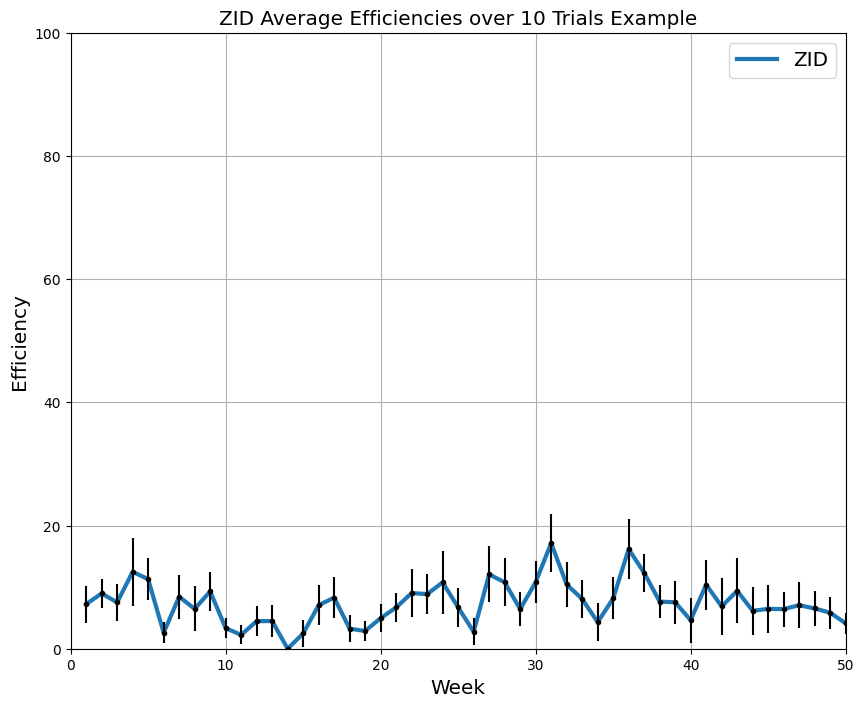

In [4]:
dm_utils.draw_efficiency(sim_data, labels='ZID', title=f'ZID Average Efficiencies over {num_trials} Trials Example')

## Example Simulation Application
### Contrasting Trader Types
The ZID traders do not appear to improve in the above simulation, nor should we expect them to, as they employ no logic in their strategy and simply behave randomly. The ZIDA traders, however, can employ a simple rule-of-thumb which leads them to stay at locations where they are succeeding at making exchanges, while leaving others.

Below we demonstrate an identical simulation to above, but changing the traders out for ZIDA traders and giving them a "WINDOW" rule with a minimum of 1 trade per 7 periods (the same number of periods as 1 week above).

Note the definition of strategy parameters - these are used by the agent to help define their strategy. If you need to see the potential strategies or the potential strategy parameters, invoke the helper in dm_utils:
```
dm_utils.agent_strategy_helper() # Prints agent class (strategy) names
dm_utils.agent_strategy_helper(agent_class_name) # Prints potential strategy parameters for an agent class
```


In [5]:
dm_utils.agent_strategy_helper()

Agent Classes Available
['ZID', 'ZIDA', 'ZIDP', 'ZIDPA', 'ZIDPR', 'ZIDT', 'ZIDTR']


In [6]:
dm_utils.agent_strategy_helper('ZIDA')

ZIDA takes "reset_flag_frequency", representing the rule on which to resume movement, as a parameter. Additional parameters may be required, as specified below.

"reset_flag_frequency" can take the values of ["NONE", "START", "WEEK", "MIN_AGENTS", "WINDOW"]

NONE: Never resume movement after trading. No additional parameters

START: Resume movement at the start of each week (every time agent.start is called). No additional parameters.

WEEK: Resume movement is did not trade at least "reset_flag_min_trades" in the past week (time between agent.start is called).

MIN_AGENTS: Resume movement is there are less than "reset_flag_min_agents" agents at the same location as this agent.

WINDOW: Resume movement is did not trade at least "reset_flag_min_trades" in the last "reset_flag_window" periods.



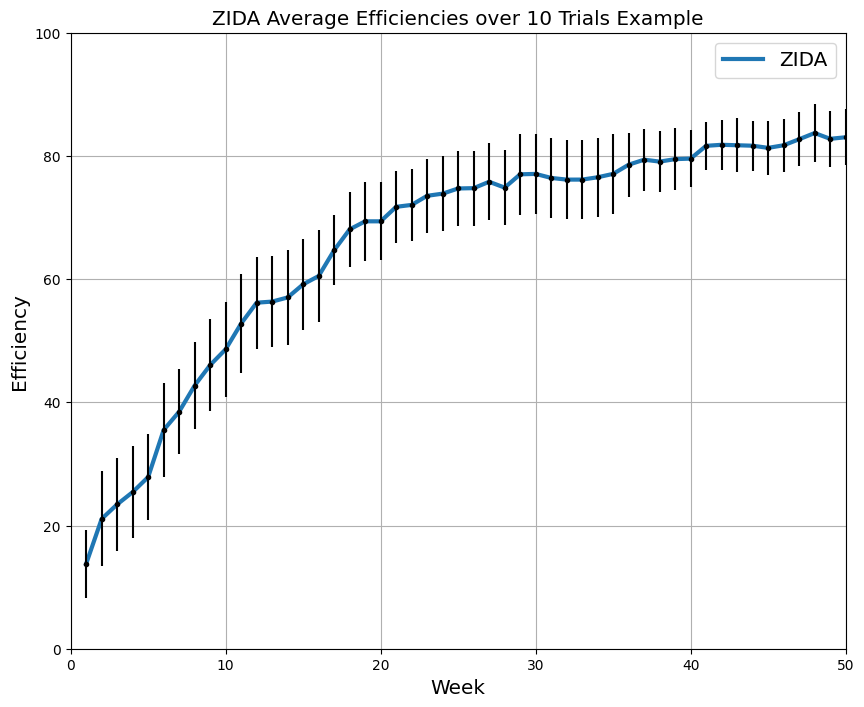

In [7]:
sim_name = "ZIDA MONTE-CARLO" # Name your simulation
num_trials = 10 # Choose the number of trials
num_weeks = 50 # Choose the number of weeks
num_periods = 7 # Choose the number of periods in week
num_rounds = 5 # Choose the number of trading rounds within a period
grid_size = 15 # Choose the grid size
num_traders = 10 # Define the number of traders - used as a verification to check agent group definition

# Define trader groups - These are the traders which will go into your simulation
proportion_sellers = 0.5
num_buyer = int(num_traders*(1-proportion_sellers)) # Note: The group size (number of agents in a group) must be an integer
num_seller = int(num_traders*(proportion_sellers))

lower_bound = 200 # Lower bound on 
upper_bound = 600
num_units = 8 # Number of units each trader demands/supplies
# starting endowments
buy_endow = 500
sell_endow = 0
move_error_rate = 0 # chance to randomly move and override movement strategy
starting_location = None # Location each agent starts at; None = randomly on grid
agent_class = 'ZIDA' # String name of the agent class - this class requires parameters

# Define the strategy parameters as a dictionary
strategy_params = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 7
                   } # Parameters required for the strategy - ZIDA and ZIDT types require inputs

buy_group = [num_buyer, 'BUYER', agent_class, strategy_params, lower_bound, upper_bound, num_units, buy_endow, 'utility', move_error_rate, starting_location]

sell_group = [num_seller, 'SELLER', agent_class, strategy_params, lower_bound, upper_bound, num_units, sell_endow, 'profit', move_error_rate, starting_location]

agent_groups = [buy_group, sell_group]

# run Monte_Carlo
sim_data = dm_sim.make_monte_carlo(sim_name, 
                                        num_trials, num_weeks, num_periods, num_rounds,
                                        num_traders, agent_groups, grid_size=grid_size)

dm_utils.draw_efficiency(sim_data, labels='ZIDA', title=f'ZIDA Average Efficiencies over {num_trials} Trials Example')


As you can see the ZIDA agents simulation global efficiency improves over the 50 weeks of the simulation. The standard deviation also decreases when the agents approach a stable equilibrium level of efficiency.

## Details on Agent Group Definition

In subsection 2.1 the simulation set a large number of control variables.  One of these sets of variables defines the agent groups. Note that the group of buyers and sellers is defined separately to allow for greater flexibility, though you can look into the env_make_agents.gen_default_agents(*) function for some simplified options.

The agent groups are defined as such:
```
agent_group = [group_size, agent_type, agent_class, strategy_params, lower_bound, upper_bound, num_units, endowment, payoff_function, move_error_rate, starting_location]
```
Each agent within an agent group is ex ante identical, though once they generate reservation values and costs upon initiation, they are no longer identical.

The values that an agent group group takes as its input are detailed below.

`group_size`: int > 0; the number of agents defined by this group

`agent_type`: a str, either "B"/"BUYER" of "S"/"SELLER"; define the role of agents defined by this group

`agent_class`: a str, one of the defined agent class names, ex. "ZID", "ZIDA"; defines the strategy behavior of the agents

`strategy_params`: None or a dict, {'parameter_name': parameter_value}; defines parameters for the agents' strategies

`lower_bound`: int > 0; the lower bound of agents' values/costs

`upper_bound`: int > lower_bound > 0; the upper bound fo agents' values/costs

`num_units`: int > 0; the number of units an agent demands/supplies during one week

`endowment`: int >= 0; the starting currency/utility value of agents - can compensate for endowment value of supplying

`payoff_function`: None or str of 'profit' or 'utility'; a string name defining the payoff function to be used for these agents. For sellers use a profit function and buyers a utility function. Superfluous in the base models, but allows for custom definitions. If None, uses defaults for buyer and seller.

`move_error_rate`: float in [0, 1]; the probability that an agent ignores their movement strategy and employs the random movement strategy. Error model is uniform and applied at the period level.

`starting_location`: None or (x, y), values of x, y in [0, grid_size-1]; the starting location of the agent, if None - starts at a random location on the grid.

### Coding Problem

It is typical in running simulations to compare the effect of changing a variable and comparing statistics, such as efficiency.  In this problem let our treatment changes be given by the list treatments as shown in the code cell below.  Your job is write a program to walk through each treatment and run a Monte_Carlo simulation for the control variables shown.  Your efficiency measures should be collected in a corresponding list so you can then plot all the measures together. You can also collect the data files in a list and use the dm_utils.draw_efficiency(*) helper function as above.

The treatments below are defined by the proportion of ZID and ZIDA agents in each simulation.

In [8]:
# Constants
grid_size = 15
num_traders = 20

num_trials = 10
num_periods = 7
num_weeks = 50
num_rounds = 5

num_units = 8
lower_bound = 200 
upper_bound = 600

buy_endow = 500
sell_endow = 0

proportion_sellers = 0.5

zid_params = None
zida_params = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 7
                }

# Treatment Differences
treatment_names = ["ZIDA_20, ZID_0", "ZIDA_16, ZID_4", "ZIDA_12, ZID_8", "ZIDA_8, ZID_12", "ZIDA_4, ZID_16", "ZIDA_0, ZID_20"]
num_zid = [0, 4, 8, 12, 16, 0]
num_zida = [20, 16, 12, 8, 4, 0]

> Hint:

Below we demonstrate how to do just the first two treatments proposed, but employ minimal automation in doing so.

Note we do not need to change any values other than the group sizes and class definitions.

In [9]:
# Treatment 0 ******************************************************************************************
tr_name = treatment_names[0]

# Define ZIDA Groups
n_zida = num_zida[0] # Total number of ZIDA traders
num_zida_b = int((1-proportion_sellers)*n_zida) # Number of ZIDA buyers - Note we must cast to int
num_zida_s = int((proportion_sellers)*n_zida) # Number of ZIDA sellers

zida_b_group = [num_zida_b, 'BUYER', 'ZIDA', zida_params, lower_bound, upper_bound, num_units, buy_endow, 'utility', move_error_rate, starting_location]

zida_s_group = [num_zida_s, 'SELLER', 'ZIDA', zida_params, lower_bound, upper_bound, num_units, sell_endow, 'profit', move_error_rate, starting_location]

# Define ZID Groups
n_zid = num_zid[0] # Total number of ZID traders
num_zid_b = int((1-proportion_sellers)*n_zid) # Number of ZID buyers
num_zid_s = int((proportion_sellers)*n_zid) # Number of ZID sellers

zid_b_group = [num_zid_b, 'BUYER', 'ZID', zid_params, lower_bound, upper_bound, num_units, buy_endow, 'utility', move_error_rate, starting_location]

zid_s_group = [num_zid_s, 'SELLER', 'ZID', zid_params, lower_bound, upper_bound, num_units, sell_endow, 'profit', move_error_rate, starting_location]

# Gather all agent group definitions
# Note the nested-list nature of ag_groups 
ag_groups = [zida_b_group, zida_s_group, zid_b_group, zid_s_group]

# Run simulation for Treatment 0
# Note we must pass a non-None grid_size as agent starting locations are None
tr0_sim = dm_sim.make_monte_carlo(tr_name, 
                                  num_trials, num_weeks, num_periods, num_rounds, num_traders, ag_groups, grid_size=grid_size)

In [10]:
# Treatment 1 ******************************************************************************************
tr_name = treatment_names[1]

# Define ZIDA Groups
n_zida = num_zida[1] # Total number of ZIDA traders
num_zida_b = int((1-proportion_sellers)*n_zida) # Number of ZIDA buyers
num_zida_s = int((proportion_sellers)*n_zida) # Number of ZIDA sellers

zida_b_group = [num_zida_b, 'BUYER', 'ZIDA', zida_params, lower_bound, upper_bound, num_units, buy_endow, 'utility', move_error_rate, starting_location]

zida_s_group = [num_zida_s, 'SELLER', 'ZIDA', zida_params, lower_bound, upper_bound, num_units, sell_endow, 'profit', move_error_rate, starting_location]

# Define ZID Groups
n_zid = num_zid[1] # Total number of ZID traders
num_zid_b = int((1-proportion_sellers)*n_zid) # Number of ZID buyers
num_zid_s = int((proportion_sellers)*n_zid) # Number of ZID sellers

zid_b_group = [num_zid_b, 'BUYER', 'ZID', zid_params, lower_bound, upper_bound, num_units, buy_endow, 'utility', move_error_rate, starting_location]

zid_s_group = [num_zid_s, 'SELLER', 'ZID', zid_params, lower_bound, upper_bound, num_units, sell_endow, 'profit', move_error_rate, starting_location]

# Gather all agent group definitions
# Note the nested-list nature of ag_groups 
ag_groups = [zida_b_group, zida_s_group, zid_b_group, zid_s_group]

# Run simulation for Treatment 0
# Note we must pass a non-None grid_size as agent starting locations are None
tr1_sim = dm_sim.make_monte_carlo(tr_name, 
                                  num_trials, num_weeks, num_periods, num_rounds, num_traders, ag_groups, grid_size=grid_size)

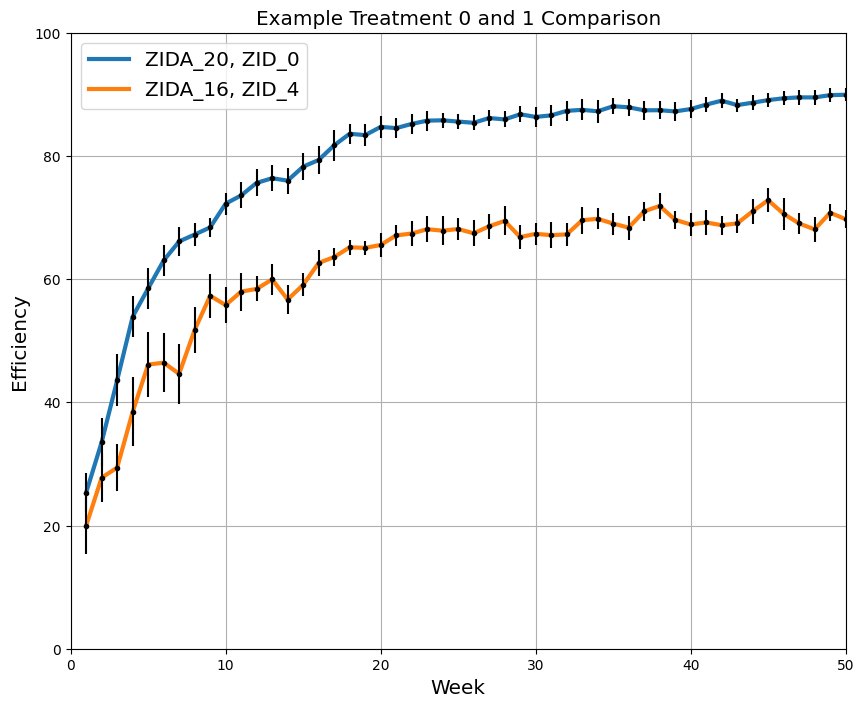

In [11]:
dm_utils.draw_efficiency([tr0_sim, tr1_sim], title=f'Example Treatment 0 and 1 Comparison')

# Agents Theory Model

## Buyer Model

Agents are a model of the decision makers in our experiment.  In this simulation we have divided agents into an equal number of buyers and sellers.  Our mathematical model of buyers is as follows:

> **Buyers** (indexed by b) 
* reservation values: $v^b = (v_1, v_2, ..., v_K), m^b$.
    *note reservation values are decreasing or $i\le j$ implies $v_i \ge v_j$.  
* quantity bought: $q^b$
* prices paid: $p^b = (p_1, ..., p_{q^b})$
* utility:
$$u^b(q^b,p^b) = m^b + \sum_{i=1}^{q^b} v^b_i - \sum_{i = 1}^{q^b} p^b_i$$
* starting position: $e^b = (v^b, m^b, u^b, loc^b)$

So some buyer, b, has values given by $v^b = (v_1, v_2, ..., v_K)$.  Before we go any further we can ask how can we generate these values on the computer.  This is done in the `dm_agents.py` code.  When you look at it you will see a method `gen_res_values` in the `ZID` class. This method uses code similar to the code shown below.

### Reservation value code

In [12]:
num_units = 8
ub = 600
lb = 0
interval = int((ub-lb)/4)
print('interval = ',interval)
high = ub + 1
low = lb 

values = []
for unit in range(num_units):
    value = np.random.randint(low, high)
    values.append(value)
res_values = sorted(values, reverse=True)
print(f"values = {values}")
print(f"reservation values = {res_values}")


interval =  150
values = [162, 117, 321, 171, 517, 514, 302, 106]
reservation values = [517, 514, 321, 302, 171, 162, 117, 106]


> Note: You can use other generators like this one

In [13]:
num_units = 8
ub = 600
lb = 0
high = ub + 1
low = lb 

values = []
for unit in range(num_units):
    value = np.random.randint(low, high)
    values.append(value)
    low = lb = int(value/2)
    high = value + 1
res_values = sorted(values, reverse=True)
print(f"values = {values}")
print(f"reservation values = {res_values}")


values = [409, 409, 363, 252, 241, 141, 137, 131]
reservation values = [409, 409, 363, 252, 241, 141, 137, 131]


Notice how this works.  
* Line 1 imports numpy
* Lines 3-8 set up to use numpy's function `random.randint(low, high)` which returns a random integer in the range low to high - 1.
* line 10 defines a list to hold values.
* lines 11-13 defines the values and puts them in the list
The list `values` is printed out to show you their random nature.  To turn these values into reservation values we have to sort them from highest to lowest using the builtin Python function `sorted` shown on line 14.   

If for some reason you want to override this function or set new, specific reservation values, you can do so using the set_values(\*) method of the Trader class in dm_agents.py. Analogously you can do so for sellers using the set_costs(\*) method.

### Plotting individual demand curves

In [14]:
def plot_ind_demand(res_values, price):
    """Plot individual demand"""
    
    dunits = [units for units in range(len(res_values) + 2)] 
    munits = len(dunits)
    max_value = res_values[0]   
    demand_values = [max_value] # sets up first step
    demand_values.extend(res_values)
    demand_values.append(0) # brings curve back down to zero

    """
    Set up plot
    """
    plt.figure(figsize=(10, 7.5))  # Set plot dimensions
    ax = plt.subplot(111)
    ax.spines["top"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    plt.yticks(fontsize=14)
    plt.xticks(fontsize=14)

    """
    Made a bunch of small changes here
    """
    plt.step(dunits, demand_values, label='Demand')
    plt.axhline(y=price, xmin=0, xmax=8, color='r', linestyle='-', linewidth=3)
    ax.annotate('PRICE', xy=(5,price), xytext=(0,5), textcoords='offset points')

    ax = plt.gca()
    plt.legend(loc='upper center', frameon=False)
    plt.title('Individual Demand')
    plt.xlabel('Units')
    plt.ylabel('Utils')

    """
    Try annotating
    """
    #for i, v in enumerate(demand_values):
    #    ax.text(i, v+5, "%d" %v, ha="center")

    for i, v in enumerate(demand_values[1:-1]):
        ax.annotate(str(v), xy=(i,v), xytext=(20,5), textcoords='offset points')
        # this works but (20, 5) is hardcoded in a not nice way

    plt.xlim(0, munits)
    plt.ylim(0, max(demand_values))
    plt.show()

# TODO: Implement A version of this function, along with a supplier version, in dm_utils

TODO - changes above

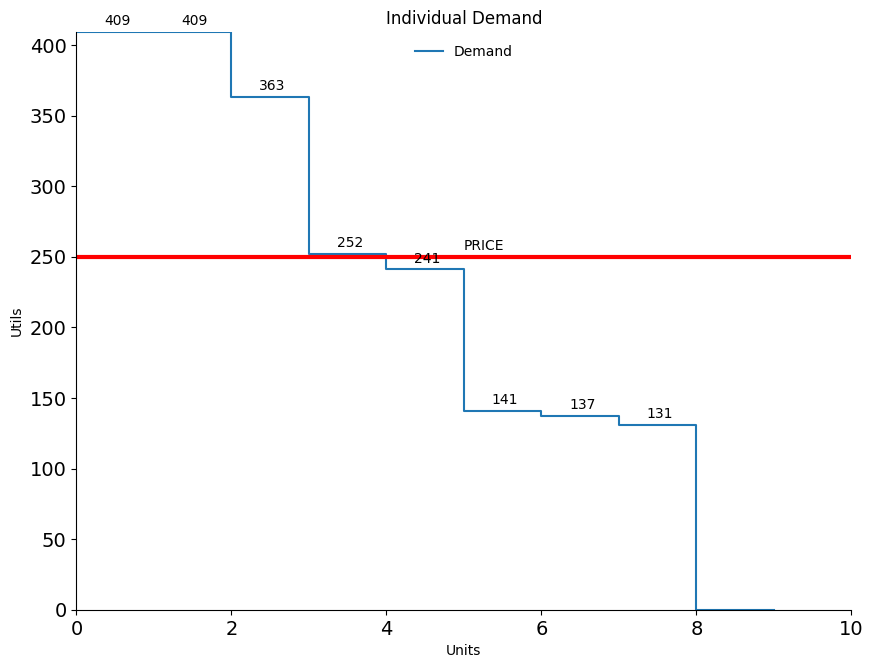

At price 250 our individual will buy 4 units and produce 433 surplus.


In [15]:
price = 250
plot_ind_demand(res_values, price)
q_units = 0
surp = 0
for val in res_values:
    if val >= price:
        q_units += 1
        surp += val-price
print (f"At price {price} our individual will buy {q_units} units \
and produce {surp} surplus.")

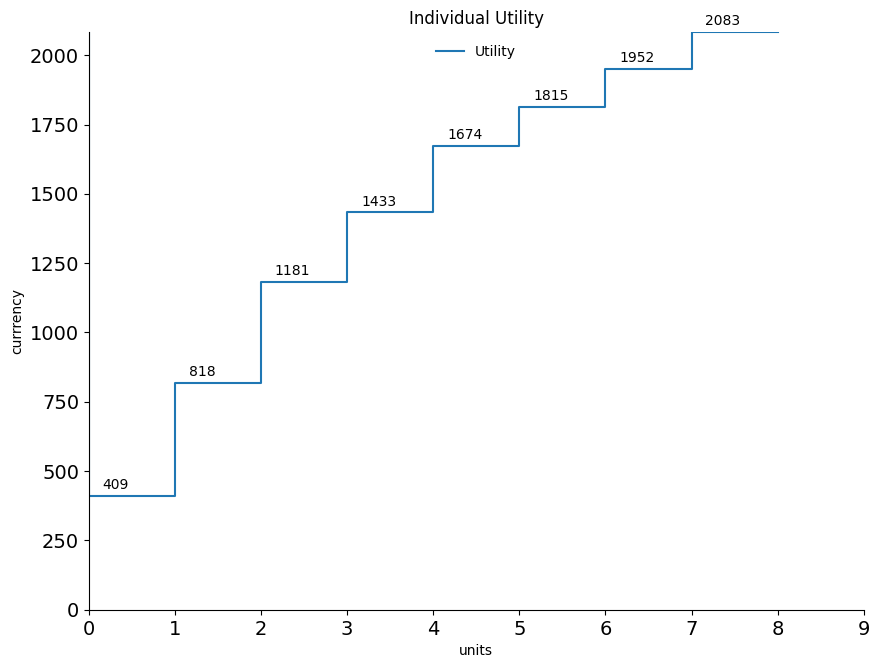

In [16]:
dunits = [units for units in range(len(res_values) + 1)] 
utility = []
util = 0
for k, val in enumerate(res_values):
    utility.append(util + val)
    util += val
munits = len(dunits)
max_value = util   
utility_values = [max_value] # sets up first step
utility_values.extend(utility)
# demand_values.append(0) # brings curve back down to zero

"""
Set up plot
"""
plt.figure(figsize=(10, 7.5))  # Set plot dimensions
ax = plt.subplot(111)
ax.spines["top"].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.get_xaxis().tick_bottom()
ax.get_yaxis().tick_left()
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)

"""
Made a bunch of small changes here
"""
plt.step(dunits, utility_values, label='Utility')

ax = plt.gca()
plt.legend(loc='upper center', frameon=False)
plt.title('Individual Utility')
plt.xlabel('units')
plt.ylabel('currrency')

"""
Try annotating
"""
#for i, v in enumerate(demand_values):
#    ax.text(i, v+5, "%d" %v, ha="center")

for i, v in enumerate(utility_values[1:]):
    ax.annotate(str(v), xy=(i,v), xytext=(10,5), textcoords='offset points')
    # this works but (30, 5) is hardcoded in a not nice way
    
plt.xlim(0, munits)
plt.ylim(0, max(utility_values))
plt.show()


## Seller Model

> **Sellers** (indexed by s) 
* unit costs: $c^s = (c_1, c_2, ..., c_K), m^s$.
    * note unit costs are increasing or $i\ge j$ implies $c_i \ge c_j$.
* quantity sold: $q^s$
* prices received: $p^s = (p_1, ..., p_{q^s})$
* profit:
$$\pi^s(q^s,p^s) = m^s + \sum_{i=1}^{q^s} p^s_i - \sum_{i = 1}^{q^s} c^s_i$$
* starting position: $e^s = (c^s, m^s, \pi^s, loc^s)$

The Seller model is analogous to the Buyer model, but generating profit form selling its produced units, rather than utility from consumption of units.

Producer surplus is therefore the difference between the price and cost, per unit.

In [17]:
# TODO visualize supply

# Designing Your Simulation

## Visualizing Supply and Demand

You can easily visualize the aggregate global supply and demand in an agent market by creating a MakeAgents object directly with your agent group definitions and using the plot_market() method of MakeAgents. You can also view the predicted equilibrium prices and quantities using the show_equilibrium() method.

We demonstrate an example of this below. Note the way in which the agents are created within MakeAgents. First we invoke the MakeAgents.gen_custom_agents(num_traders, agent_groups, grid_size), which returns a pandas DataFrame which defines agent-level initialization data. This DataFrame is then fed into MakeAgents.init_agents(trader_data) to create the list of agents.

We then invoke MakeAgents to create a spot market and to run calculations, before we can retrieve the results and market curves.

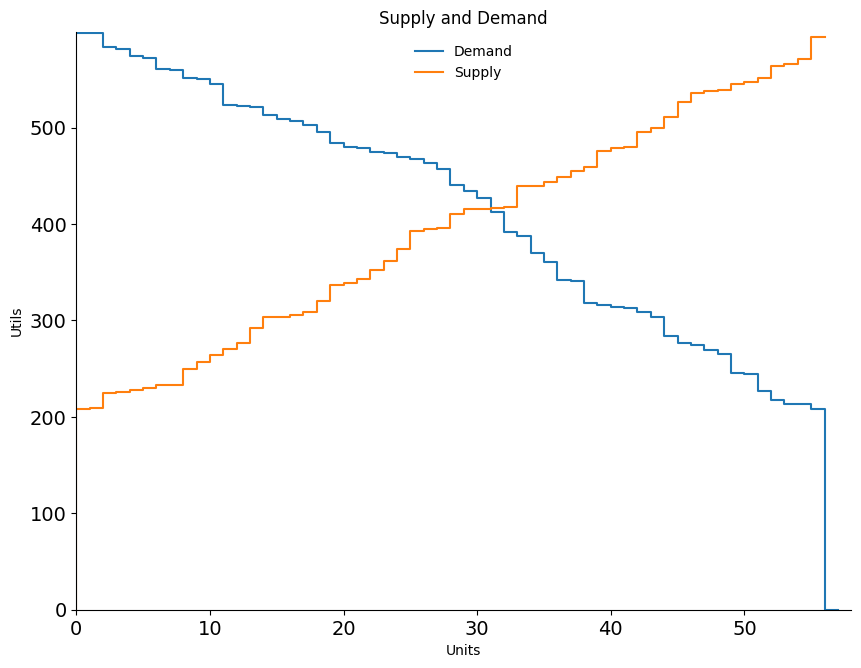


When market Example Market is in equilibrium we have:
equilibrium price    = 416 - 417
equilibrium quantity = 31
maximum surplus      = 6442



In [18]:
num_traders = 10
grid_size = 10

num_ag = 5
zid_params = None
lower_bound = 200
upper_bound = 600
num_units = 8
endowments = [500, 0]
move_error_rate = 0
starting_location = None

buy_group = [num_ag, 'BUYER', 'ZID', zid_params, lower_bound, upper_bound, num_units, endowments[0], 'utility', move_error_rate, starting_location]
sell_group = [num_ag, 'SELLER', 'ZID', zid_params, lower_bound, upper_bound, num_units, endowments[1], 'profit', move_error_rate, starting_location]

ag_groups = [buy_group, sell_group, zid_b_group, zid_s_group]

# Create the agents inside MakeAgents
agent_maker = env_make_agents.MakeAgents()
tr_data = agent_maker.gen_custom_agents(num_traders, ag_groups, grid_size)
agent_maker.init_agents(tr_data)

# Invoke spot market creation and calculation
agent_maker.make_market(market_name="Example Market") # Naming the market is optional
agent_maker.plot_market() # Plot the market curves
agent_maker.show_equilibrium() # Print the equilibrium

## Simplifying Agent Group Generation

Now that you should be familiar with the intricacies of agent group definition, below we introduce a helper function to allow for simple agent group definition if you would prefer to follow a formula rather than define each group individually.

The helper function is defined in dm_utils.gen_agent_groups(*). It takes the same parameters as the agent group definition. Each parameter can be a single value or a list of values. If you pass a list, there will be an agent group created for each value, matching across any other values you defined as a list, such that number of groups will be equal to the length of passed value lists. All lists musts be of the same length.

There is an additional keyword argument, `return_names`, a flag to generate custom group names for agents. These names can be used for grouping ex ante identical agents in the analysis models. You can also use custom defined agent group names if these do not suit your purpose.

In [19]:
# Across-group constants
agent_num = 5
lower_bound = 200
upper_bound = 600
num_units = 8
payoff_function = None # Note - passing None to use the default of profit and utility
move_error_rate = 0
starting_location = None # Note - passing None to start at a random location

# Group-specific input - note the lists are of length 4 for 4 groups
agent_type = ['BUYER', 'SELLER', 'BUYER', 'SELLER']
agent_class = ['ZID', 'ZID', 'ZIDA', 'ZIDA']
zida_params = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 7
                }
strategy_params = [None, None, zida_params, zida_params]
endowment = [500, 0, 500, 0]

# Generate definitions for a group and ask for group names
ag_groups, ag_names = dm_utils.gen_agent_groups(agent_num, agent_type, agent_class, strategy_params, lower_bound, upper_bound, num_units, endowment, payoff_function, move_error_rate, starting_location, return_names=True)

In [20]:
# Prettily print the agent groups and names
for i in range(len(ag_groups)):
    print(ag_names[i])
    print(ag_groups[i])
    print()

BUYER_ZID_gr_0
[5, 'BUYER', 'ZID', None, 200, 600, 8, 500, None, 0, None]

SELLER_ZID_gr_1
[5, 'SELLER', 'ZID', None, 200, 600, 8, 0, None, 0, None]

BUYER_ZIDA_gr_2
[5, 'BUYER', 'ZIDA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, 500, None, 0, None]

SELLER_ZIDA_gr_3
[5, 'SELLER', 'ZIDA', {'reset_flag_frequency': 'WINDOW', 'reset_flag_min_trades': 1, 'reset_flag_window': 7}, 200, 600, 8, 0, None, 0, None]



## Returning Results with DataFrames
In order to facilitate deeper analysis of the simulations, we have designed a pandas-based implementation of the simulation package.

To access this behavior, simply pass the keyword argument return_df=True to dm_sim.make_sim(\*) or dm_sim.make_monte_carlo(\*). Below we demonstrate this behavior, as this data format will be used going forward.

In [21]:
num_trials = 10
num_weeks = 50
num_periods = 7
num_rounds = 5
num_traders = 20
grid_size = 15
# TODO: implement function agent_groups = dm_utils.gen_test_agents(agent_class=None, ) - right now using ag_groups from above 

sim1_data = dm_sim.make_sim('one_sim_ex', 
                            num_weeks, num_periods, num_rounds,
                            num_traders, ag_groups, 
                            grid_size=grid_size, group_names=ag_names,
                            return_df=True)


mc_data = dm_sim.make_monte_carlo('mc_example', 
                                   num_trials, num_weeks, num_periods, num_rounds,
                                   num_traders, ag_groups,
                                   grid_size=grid_size, group_names=ag_names,
                                   return_df=True)

In [22]:
sim1_data.head()

,sim_name,num_weeks,num_periods,num_rounds,num_traders,agent_groups,grid_size,group_names,week,contracts,grids,eff,class_surplus,group_surplus
0,one_sim_ex,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",0,"[(0, 443, BUYER_10_ZIDA, SELLER_17_ZIDA, 0, 57...","[{(8, 10): ['BUYER_0_ZID'], (11, 0): ['BUYER_1...",21.963277,"{'ZID': 442, 'ZIDA': 1113}","{'BUYER_ZID_gr_0': 306, 'SELLER_ZID_gr_1': 136..."
1,one_sim_ex,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",1,"[(0, 227, BUYER_10_ZIDA, SELLER_17_ZIDA, 0, 57...","[{(6, 13): ['BUYER_0_ZID'], (9, 1): ['BUYER_1_...",32.641243,"{'ZID': 763, 'ZIDA': 1548}","{'BUYER_ZID_gr_0': 210, 'SELLER_ZID_gr_1': 553..."
2,one_sim_ex,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",2,"[(0, 328, BUYER_10_ZIDA, SELLER_17_ZIDA, 0, 57...","[{(6, 10): ['BUYER_0_ZID'], (8, 0): ['BUYER_1_...",37.867232,"{'ZID': 913, 'ZIDA': 1768}","{'BUYER_ZID_gr_0': 639, 'SELLER_ZID_gr_1': 274..."
3,one_sim_ex,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",3,"[(0, 496, BUYER_10_ZIDA, SELLER_17_ZIDA, 0, 57...","[{(11, 12): ['BUYER_0_ZID'], (11, 1): ['BUYER_...",24.364407,"{'ZID': 491, 'ZIDA': 1234}","{'BUYER_ZID_gr_0': 159, 'SELLER_ZID_gr_1': 332..."
4,one_sim_ex,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",4,"[(0, 496, BUYER_10_ZIDA, SELLER_17_ZIDA, 0, 57...","[{(8, 10): ['BUYER_0_ZID'], (12, 4): ['BUYER_1...",24.039548,"{'ZID': 131, 'ZIDA': 1571}","{'BUYER_ZID_gr_0': 0, 'SELLER_ZID_gr_1': 131, ..."


In [23]:
mc_data.head()

,sim_name,num_weeks,num_periods,num_rounds,num_traders,agent_groups,grid_size,group_names,week,contracts,grids,eff,class_surplus,group_surplus,trial
0,mc_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",0,"[(0, 395, BUYER_1_ZID, SELLER_9_ZID, 0, 533, 0...","[{(9, 7): ['BUYER_0_ZID'], (13, 6): ['BUYER_1_...",10.722458,"{'ZID': 656, 'ZIDA': 0}","{'BUYER_ZID_gr_0': 298, 'SELLER_ZID_gr_1': 358...",0
1,mc_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",1,"[(0, 279, BUYER_1_ZID, SELLER_8_ZID, 0, 533, 0...","[{(11, 8): ['BUYER_0_ZID'], (14, 9): ['BUYER_1...",25.024518,"{'ZID': 1192, 'ZIDA': 339}","{'BUYER_ZID_gr_0': 717, 'SELLER_ZID_gr_1': 475...",0
2,mc_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",2,"[(0, 500, BUYER_0_ZID, SELLER_16_ZIDA, 0, 595,...","[{(9, 7): ['BUYER_0_ZID', 'SELLER_16_ZIDA'], (...",27.819549,"{'ZID': 995, 'ZIDA': 707}","{'BUYER_ZID_gr_0': 545, 'SELLER_ZID_gr_1': 450...",0
3,mc_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",3,"[(0, 539, BUYER_4_ZID, SELLER_8_ZID, 0, 567, 0...","[{(10, 5): ['BUYER_0_ZID'], (12, 14): ['BUYER_...",36.155606,"{'ZID': 1872, 'ZIDA': 340}","{'BUYER_ZID_gr_0': 1193, 'SELLER_ZID_gr_1': 67...",0
4,mc_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",4,"[(1, 530, BUYER_0_ZID, SELLER_16_ZIDA, 0, 595,...","[{(9, 7): ['BUYER_0_ZID', 'SELLER_16_ZIDA'], (...",19.777705,"{'ZID': 599, 'ZIDA': 611}","{'BUYER_ZID_gr_0': 363, 'SELLER_ZID_gr_1': 236...",0


## Analyzing Different Agent Varieties

As in the example coding problem, you are able to mix different types of agents in a simulation. Below we generate a mixed-type simulation to investigate the performance of different agent types within the simulation.

The analysis model allows you to cut agents into different groups, with the smallest allowable group (save for individual agents) being the agent_group as defined in agent creation.

Below we demonstrate analysis with grouping of agents at the agent_class and agent_group level. You can notice a calculated surplus for agent classed and for agent groups in the above DataFrames. Note however, that the values are surpluses, not efficiencies, so they are not normalized for potential surplus and group sizes, so these values should be compared across groups which would be otherwise identical (cateris paribus analysis).

### Agent Classes (Strategies)

In [24]:
# Get agent_class surpluses in a nice format
ac_surpluses = dm_utils.long_class_surplus(mc_data)
ac_surpluses.head()

,sim_name,week,trial,agent_class,class_surplus_val
0,mc_example,0,0,ZID,656
1,mc_example,0,0,ZIDA,0
2,mc_example,1,0,ZID,1192
3,mc_example,1,0,ZIDA,339
4,mc_example,2,0,ZID,995


In [25]:
# Get weekly standard deviation and average values for class_surplus_val by agent_class
# You must exclude sim_name here or group by it, if you want to compare across different simulations
st_surpluses = ac_surpluses.drop(columns='trial')
id_cols = ['sim_name', 'agent_class', 'week']

# Calculate avg
avg_val = st_surpluses.groupby(by=id_cols).mean()
avg_val = avg_val.rename(columns={'class_surplus_val':'csv_avg'})

# Calculate sem
sem_val = st_surpluses.groupby(by=id_cols).sem()
sem_val = sem_val.rename(columns={'class_surplus_val':'csv_sem'})

merged_df = avg_val.merge(sem_val, on=id_cols).reset_index()
merged_df.head()

,sim_name,agent_class,week,csv_avg,csv_sem
0,mc_example,ZID,0,639.3,188.559631
1,mc_example,ZID,1,567.9,134.385552
2,mc_example,ZID,2,776.8,156.627144
3,mc_example,ZID,3,452.7,176.233056
4,mc_example,ZID,4,662.1,146.915807


Now we graph the mean and standard error of the median for the surplus of each agent_class per week.

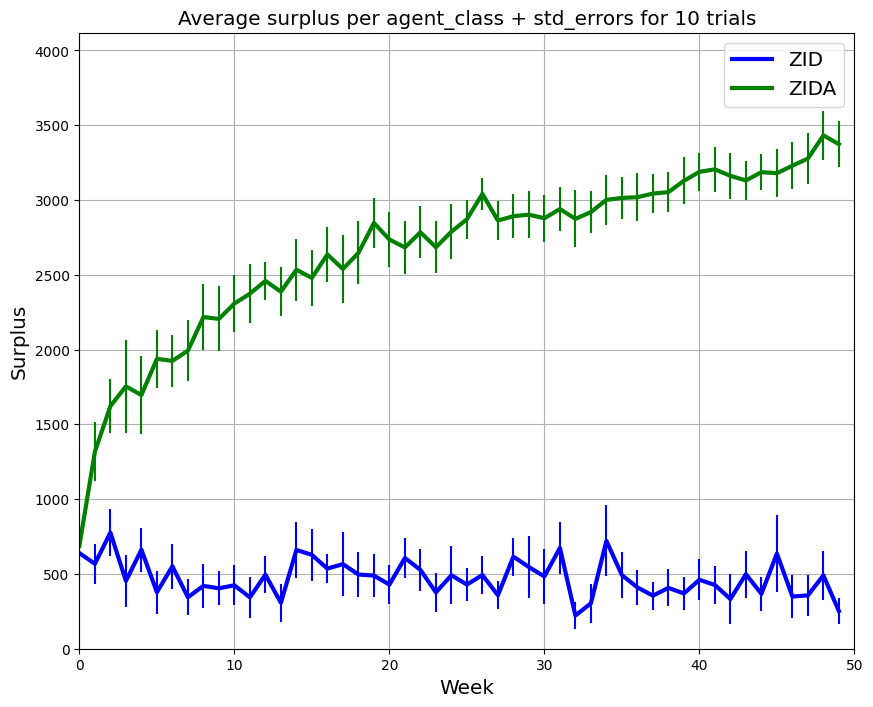

In [26]:
# Cut merged DataFrame by the agent_class
mzid = merged_df[merged_df['agent_class']=='ZID']
mzida = merged_df[merged_df['agent_class']=='ZIDA']

x = [k for k in range(num_weeks)]
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(x, mzid['csv_avg'], label = 'ZID', linestyle = 'solid', color='blue', lw =3)
ax.errorbar(x, mzid['csv_avg'], yerr=mzid['csv_sem'], color='blue')

ax.plot(x, mzida['csv_avg'], label = 'ZIDA', linestyle = 'solid', color='green', lw =3)
ax.errorbar(x, mzida['csv_avg'], yerr=mzida['csv_sem'], color = 'green')

ax.set_xlabel('Week', size = 'x-large') 
ax.set_xbound(0, num_weeks)
ax.set_ybound(0, max(mzida['csv_avg'])*1.2)
ax.grid(1)
ax.set_ylabel('Surplus', size = 'x-large') 
ax.set_title(f'Average surplus per agent_class + std_errors for {num_trials} trials', size = 'x-large')
ax.legend(fontsize='x-large')
plt.show()

### Agent Groups (Ex Ante Homogenous)

You can do the same with the agent_group surpluses, analogously to the above with `dm_utils.long_group_surplus(week_df)`.

You can also use the function in `dm_utils.summary_surplus(week_df)` to get a DataFrame returned with averages, standard deviations and standard errors of surpluses by agent_class and agent_group, as well as efficiencies, from the weekly DataFrame. The function returns three DataFrames, cut by None (efficiencies), agent_class, agent_group.

We demonstrate this behavior below.

In [27]:
eff_sum, class_sum, group_sum = dm_utils.summary_surplus(mc_data)
group_sum.head()

,index,sim_name,agent_group,week,gsv_avg,gsv_std,gsv_sem
0,0,mc_example,BUYER_ZIDA_2,0,367.0,404.050602,127.772019
1,1,mc_example,BUYER_ZIDA_2,1,634.0,394.533198,124.762352
2,2,mc_example,BUYER_ZIDA_2,2,793.6,493.027202,155.908891
3,3,mc_example,BUYER_ZIDA_2,3,825.3,581.185579,183.787017
4,4,mc_example,BUYER_ZIDA_2,4,908.2,538.224406,170.201501


You can pass any of these summary DataFrame to the dm_utils.graph_summary(sum_df, by), where by = None (efficiency), 'agent_class' or 'agent_group'.

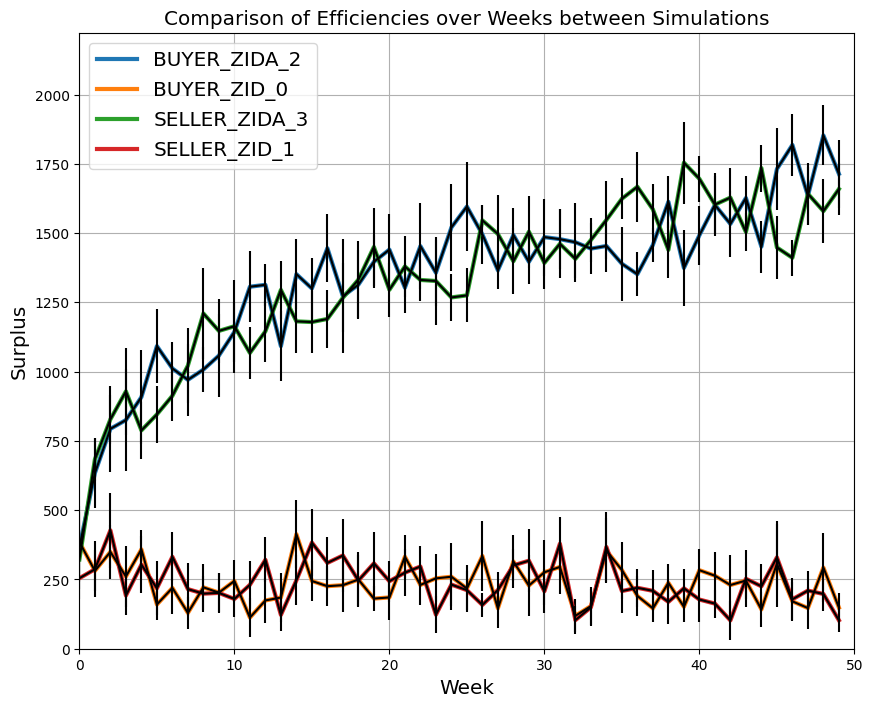

In [28]:
dm_utils.graph_summary(group_sum, by='agent_group')

# Applying Simulations to Experiments

If you were able to execute the above cells without issue, you should be set up correctly and can proceed deeper into the user guide.

In this portion we dig deeper into the structure of the simulations and provide functions to help develop experiments with simulations.

## Program Flow

The below diagram lays out the steps in order that take place within one Monte Carlo of simulations. While the default is to run the simulation in this configuration, it is possible to modularly run individual component sections.

![Program Flow](../assets/program_flow.jpg)

## Period-Level Data

So far we have focused on analyzing the results of simulations on a week-by-week basis, looking at the efficiencies and surpluses. However, it is possible to retrieve information from simulations at the period level - allowing one to analyze the movement of agents directly.

To do this, simply pass return_period_df=True to dm_sim.make_monte_carlo(\*) or dm_sim.make_sim(\*). Note however that this will substantially increase execution time and memory requirements if your simulation is big or you request many trials.

We demonstrate this behavior below. Note that this function returns two DataFrames, one for the weekly data and one for period data.

In [29]:
wk_data, per_data = dm_sim.make_monte_carlo('period_example', 
                                   num_trials, num_weeks, num_periods, num_rounds,
                                   num_traders, ag_groups,
                                   grid_size=grid_size, group_names=ag_names,
                                   return_df=True, return_period_df=True)

per_data.head()

# TODO: check why i have both grids and period_locs

,sim_name,num_weeks,num_periods,num_rounds,num_traders,agent_groups,grid_size,group_names,week,contracts,grids,eff,class_surplus,group_surplus,period,period_locs,trial
0,period_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",0,[],"{(12, 10): ['BUYER_0_ZID'], (2, 3): ['BUYER_1_...",None,None,None,0,"{(12, 10): ['BUYER_0_ZID'], (2, 3): ['BUYER_1_...",0
1,period_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",-1,[],"{(13, 11): ['BUYER_0_ZID'], (1, 3): ['BUYER_1_...",None,None,None,-1,"{(13, 11): ['BUYER_0_ZID'], (1, 3): ['BUYER_1_...",0
2,period_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",0,[],"{(12, 10): ['BUYER_0_ZID'], (1, 4): ['BUYER_1_...",None,None,None,1,"{(12, 10): ['BUYER_0_ZID'], (1, 4): ['BUYER_1_...",0
3,period_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",0,[],"{(11, 9): ['BUYER_0_ZID'], (2, 3): ['BUYER_1_Z...",None,None,None,2,"{(11, 9): ['BUYER_0_ZID'], (2, 3): ['BUYER_1_Z...",0
4,period_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",0,[],"{(10, 9): ['BUYER_0_ZID'], (2, 3): ['BUYER_1_Z...",None,None,None,3,"{(10, 9): ['BUYER_0_ZID'], (2, 3): ['BUYER_1_Z...",0


## Agent Locations and Contracts
### Movement Rules
Agents move according to their strategy, but are constrained in their decision making by the spatial reality of the grid. The grid is a gXg square grid, which in the examples above has been 15x15, but can in theory be any square.

Agents can move 1 unit in any direction at the beginning of each period, before trading, including the period right after initiation. Moreover, the grid has hard boundaries, which restricts the agents from moving past its border.

In practice, this means that when agents randomly choose a new location to move to, they choose one of nine positions, defined by +/- 1 of their x and y positions as well as their current location. If the agent is on a boundary, however, the illegal positions x,y<0 or x,y>grid_size-1 are stripped from their choice set, making the other locations more probable.

Arguments could be made about this creating "unnatural" Shelling points around the borders of the grid, however these may be analogous to borders of real-world search spaces.

Moreover, we caution against comparison of square and toroidal spatial models. One reason we chose the square model is its more intuitive nature, thus making it easier to understand in future lab experiments with human subjects.

### Agent Location Data

As you can see in the per_data period-level DataFrame above, the simulation saves a dictionary mapping occupied grid locations to a list of agent names which occupy these locations. The implied value of occupants for other locations is None - though this is not saved explicitly.

In [30]:
# Display an example of the period_locs data
per_data['period_locs'].iloc[0]

{(12, 10): ['BUYER_0_ZID'],
 (2, 3): ['BUYER_1_ZID'],
 (0, 11): ['BUYER_2_ZID'],
 (13, 7): ['BUYER_3_ZID'],
 (5, 11): ['BUYER_4_ZID'],
 (13, 3): ['SELLER_5_ZID'],
 (1, 13): ['SELLER_6_ZID'],
 (0, 12): ['SELLER_7_ZID'],
 (8, 7): ['SELLER_8_ZID'],
 (7, 6): ['SELLER_9_ZID'],
 (7, 1): ['BUYER_10_ZIDA'],
 (14, 8): ['BUYER_11_ZIDA'],
 (1, 5): ['BUYER_12_ZIDA'],
 (11, 2): ['BUYER_13_ZIDA'],
 (11, 12): ['BUYER_14_ZIDA'],
 (11, 1): ['SELLER_15_ZIDA'],
 (9, 13): ['SELLER_16_ZIDA'],
 (7, 11): ['SELLER_17_ZIDA'],
 (6, 14): ['SELLER_18_ZIDA'],
 (10, 6): ['SELLER_19_ZIDA']}

### Contract Data

Similarly to the agent location data, contract data is associated to a particular location at which this contract was made and transacted. Locations not mentioned are assumed to have no contracts for the period/week. Moreover, as the transaction rules require the contract to be for exactly one unit, the number of contracts is identical to the unit transacted volume.

In [31]:
# Display an example of the contracts data
per_data['contracts'].iloc[30] # We pull from a random with-period because the chance of contracts is higher than at the 0th period

[(0, 424, 'BUYER_13_ZIDA', 'SELLER_19_ZIDA', 3, 524, 3, 365, (9, 4), (9, 4)),
 (1, 384, 'BUYER_13_ZIDA', 'SELLER_19_ZIDA', 4, 486, 4, 384, (9, 4), (9, 4))]

## Transform Location and Contract Data to Measures
We can transform this data into more useful information, such as the number and concentration of agents at particular points, as well as measures which account for the types of agents.

For ease of analysis, we have developed functions which transform these data into such measures. You can peruse them in dm_res_helpers.

The metrics are added and documented in the functions:
- add_period_volume(\*) - adds volume of trade at period
- add_agent_density(\*) - adds a measure of agent counts at locations - by periods, add_agent_density(week_df, by_period=False, return_df=True)- adds a measure of agent counts at locations - by weeks
- add_period_price(n_df) - add prices of contracts by period
- add_location_prices(n_df) - adds prices at different locations by period
- add_week_prices(n_df) - add prices by week
- add_week_location_prices(n_df) - adds prices by week by location
- add_match_density(n_df, by_locs=True, by_counts=True) - adds measures of match counts (buyer + seller = 1), and its density (relative to potential max)
- add_match_density(n_df, by_locs=True, by_counts=False) - adds a measure of match counts (buyer + seller = 1, but 1 < ( n>1 buyers + 1 seller) < 2), and its density (relative to potential max)

There is also an omnibus function which adds all of these metrics dm_res_helpers.add_all_metrics(week_df, period_df). This function returns a copy of the original DataFrame with the added metrics, but it does remove the initial starting position of agents. This initial position is meaningless in all our analyses as it is random.

The omnibus function also adds a value "tr_period" which is a period-count which spans the entire simulations, allowing period-to-period analysis across weeks.

In [35]:
met_df = dm_res_helpers.add_all_metrics(wk_data, per_data)

# Display from second week - there are more matches at this point
met_df[14:].head()

/Users/alex/Repos/dm_markets/.venv/lib/python3.11/site-packages/pandas/core/algorithms.py:1743: RuntimeWarning: Mean of empty slice
  return lib.map_infer(values, mapper, convert=convert)
/Users/alex/Repos/dm_markets/.venv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,sim_name,num_weeks,num_periods,num_rounds,num_traders,agent_groups,grid_size,group_names,week,contracts,...,agent_types,agent_type_counts,match_count,tr_match_count,loc_match_count,loc_tr_match_count,match_density,tr_match_density,loc_match_density,loc_tr_match_density
14,period_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",2,"[(0, 283, BUYER_13_ZIDA, SELLER_19_ZIDA, 0, 57...",...,"[BUYER, SELLER]","[10, 10]",1.00,1,"(((9, 4), 1),)","(((9, 4), 1),)",0.100,0.1,"(((9, 4), 0.1),)","(((9, 4), 0.1),)"
15,period_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",2,[],...,"[BUYER, SELLER]","[10, 10]",1.25,1,"(((9, 4), 1.25),)","(((9, 4), 1),)",0.125,0.1,"(((9, 4), 0.125),)","(((9, 4), 0.1),)"
16,period_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",2,"[(0, 297, BUYER_11_ZIDA, SELLER_9_ZID, 0, 528,...",...,"[BUYER, SELLER]","[10, 10]",2.00,2,"(((9, 9), 1), ((9, 4), 1))","(((9, 9), 1), ((9, 4), 1))",0.200,0.2,"(((9, 9), 0.1), ((9, 4), 0.1))","(((9, 9), 0.1), ((9, 4), 0.1))"
17,period_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",2,[],...,"[BUYER, SELLER]","[10, 10]",1.00,1,"(((9, 4), 1),)","(((9, 4), 1),)",0.100,0.1,"(((9, 4), 0.1),)","(((9, 4), 0.1),)"
18,period_example,50,7,5,20,"[[5, BUYER, ZID, None, 200, 600, 8, 500, None,...",15,"[BUYER_ZID_gr_0, SELLER_ZID_gr_1, BUYER_ZIDA_g...",2,"[(0, 454, BUYER_13_ZIDA, SELLER_19_ZIDA, 4, 48...",...,"[BUYER, SELLER]","[10, 10]",1.00,1,"(((9, 4), 1),)","(((9, 4), 1),)",0.100,0.1,"(((9, 4), 0.1),)","(((9, 4), 0.1),)"


## Displaying Data With Boxplots
We can of course display these measures graphically. The measures are at the period level - so we can display them in this way as well.

However as the measures are potentially very noisy, we want a better way to capture this noise in the graphics. For this purpose we can use box and whisker plots at the period or week level.

Such a graphical display however requires specific data formatting inputs - so we developed functions both to coerce the data into the proper format and then to display it - an example of both is shown below, displaying the evolution of match_density (a normalized measure of full and partial matches) over the 50 simulated weeks.

Functions demonstrated:
- nb_helpers.format_df_for_boxplot(metric_df, observation_frequency, observation_value) - format a metric aggregated by observation_frequency into a boxplotting format
- nb_help.plot_boxplot_data(\[formatted_df\]) - plot a list of formatted dataframes. If instead passing as a single frame, wraps it in a list.

Note: these two functions are not compatible with treatment-level definitions. Please cut your DataFrames to one-treatment objects before using these, as you will end up with nonsense.


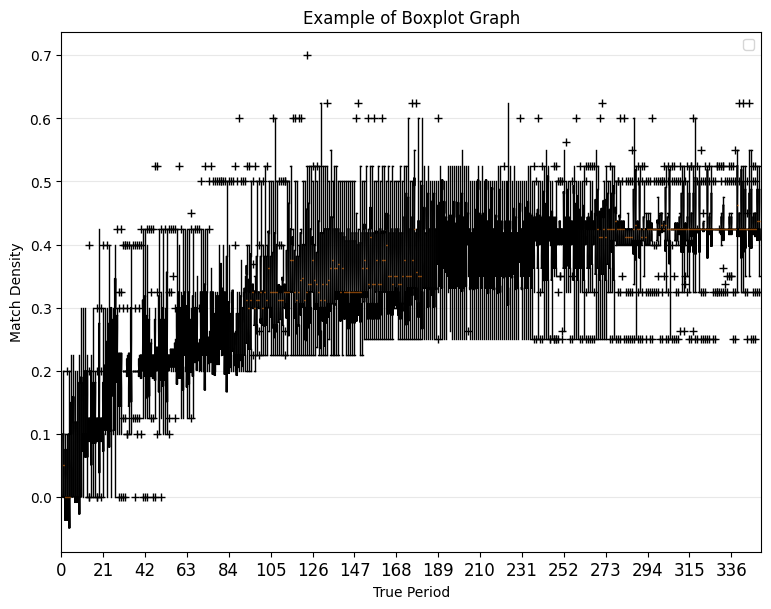

<Figure size 640x480 with 0 Axes>

In [48]:
# TODO: TO-Boxplot format DF match density
# Note the aggregator passed here - tr_period
met_tmd = nb_helpers.format_df_for_boxplot(met_df, 'tr_period', 'match_density')

# We pass custom title and labels for clarity
ttl = "Example of Boxplot Graph"
labs = ["Match Density"]
ylab = "Match Density"
xlab = "True Period"

# We pass a custom xticks, xlim definitions to make the graph less busy 
xmax = max(met_df['tr_period'])+1 # Note - pulled from met_df, not met_tmd - that is just a list of numbers
incr = 21
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)

# Plot the boxplot data - note the high level of flexibility for display inputs
nb_helpers.plot_boxplot_data(met_tmd, title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm)

# TODO: Fix Orientation thing on boxplots

Clearly the above graph is far too busy - the observation frequency is inappropriate. We can instead use the week-level observation of match density, which we do below.

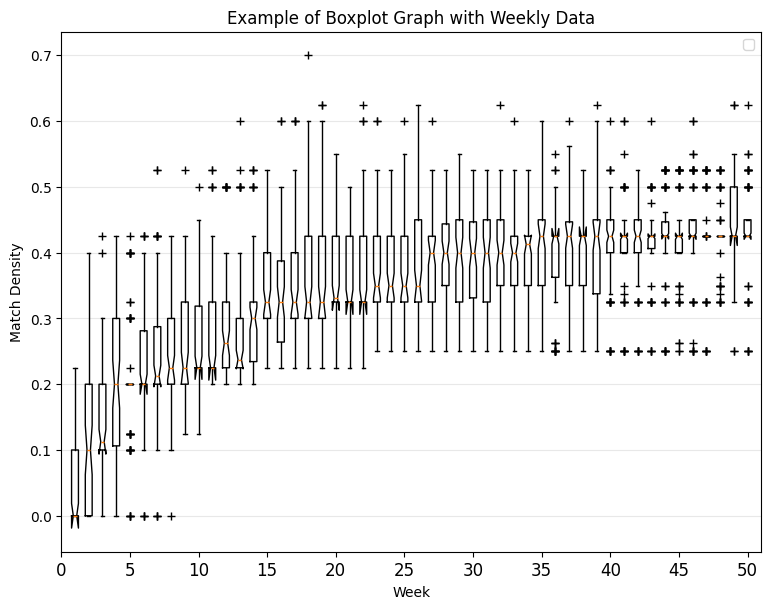

<Figure size 640x480 with 0 Axes>

In [47]:
week_tmd = nb_helpers.format_df_for_boxplot(met_df, 'week', 'match_density')

# We pass custom title and labels for clarity
ttl = "Example of Boxplot Graph with Weekly Data"
labs = ["Match Density"]
ylab = "Match Density"
xlab = "Week"

# We pass a custom xticks, xlim definitions to make the graph less busy 
xmax = max(met_df['week'])+1 # Note - pulled from met_df, not met_tmd - that is just a list of numbers
incr = 5
xtc = np.arange(0, xmax+1, incr)
xlm = (0, xmax+1)

# Plot the boxplot data - note the high level of flexibility for display inputs
nb_helpers.plot_boxplot_data(week_tmd, title=ttl, 
                             y_lab=ylab, x_lab=xlab, 
                             x_ticks=xtc, rbars=None, savename=None, legend=True, labels=labs, xlim=xlm)

## Creating an Experiment

The quintessential experiment is defined by running simulations, or in reality Monte Carlos thereof, with nearly identical inputs, but changing just one thing at a time.

It should be obvious how to do so in this simulation framework - change just one of the components the simulation inputs or agent_group definitions and run otherwise identical simulations.

Below we demonstrate a simple experiment - comparing three different grid_sizes: 10x10, 15x15, and 20x20 - while keeping all other variables the same. We can do so by simply running Monte Carlos, passing the set definitions.

In [31]:
# Control Inputs
num_trials = 10
num_weeks = 50
num_periods = 7
num_rounds = 5
num_traders = 10

# Agent Group Inputs
agent_num = 5
lower_bound = 200
upper_bound = 600
num_units = 8
payoff_function = None
move_error_rate = 0
starting_location = None

# Group-specific input
agent_type = ['BUYER', 'SELLER']
agent_class = ['ZIDA', 'ZIDA']
zida_params = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 7
                }
strategy_params = [zida_params, zida_params]
endowment = [500, 0]

# Generate definitions for a group and ask for group names
ag_groups, ag_names = dm_utils.gen_agent_groups(agent_num, agent_type, agent_class, strategy_params, lower_bound, upper_bound, num_units, endowment, payoff_function, move_error_rate, starting_location, return_names=True)

tr10 = dm_sim.make_monte_carlo('grid_size_10', 
                                   num_trials, num_weeks, num_periods, num_rounds,
                                   num_traders, ag_groups,
                                   grid_size=10, group_names=ag_names,
                                   return_df=True)

tr15 = dm_sim.make_monte_carlo('grid_size_15', 
                                   num_trials, num_weeks, num_periods, num_rounds,
                                   num_traders, ag_groups,
                                   grid_size=15, group_names=ag_names,
                                   return_df=True)

tr20 = dm_sim.make_monte_carlo('grid_size_20', 
                                   num_trials, num_weeks, num_periods, num_rounds,
                                   num_traders, ag_groups,
                                   grid_size=20, group_names=ag_names,
                                   return_df=True)

Now that we generated the monte carlo outputs, we get the summary DataFrames to allow us to easily visualize the differences between the treatments.

In [ ]:
tr10_eff, tr10_class, tr10_group = dm_utils.summary_surplus(tr10)
tr15_eff, tr15_class, tr15_group = dm_utils.summary_surplus(tr15)
tr20_eff, tr20_class, tr20_group = dm_utils.summary_surplus(tr20)

dm_utils.graph_summary(tr10_eff, by=None)
dm_utils.graph_summary(tr15_eff, by=None)
dm_utils.graph_summary(tr20_eff, by=None)

It appears obvious that increasing the grid_size makes it more difficult to reach a high level of efficiency - but comparing across graphs like this is quite difficult.

For the simple measure of efficiency - which is unique for a simulation-week level - you can instead use the function dm_utils.plot_comp_efficiencies(\[sum_df\]) - passing a list of summary DataFrames.

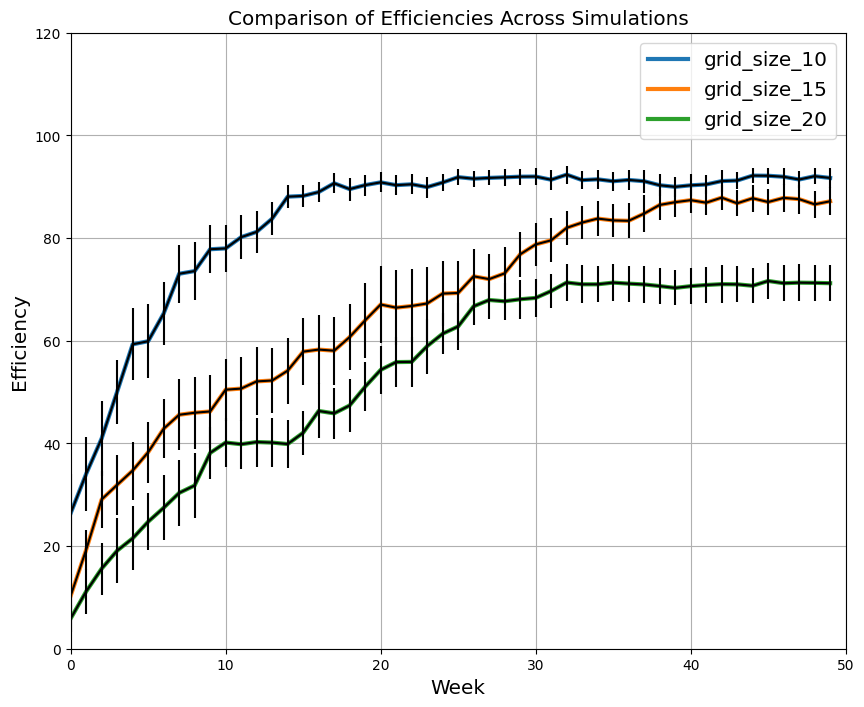

In [36]:
# TODO: Refactor code to not have flat try-excepts
dm_utils.plot_comp_efficiencies([tr10_eff, tr15_eff, tr20_eff])

## Simplifying Experiment Definition

As with agent_group definition, it can be tedious to define experiments in the way above - instead you can use the function dm_sim_experiment.make_experiment(sim_vars, treatment_dict, treatment_names=None).

`sim_vars` is a dictionary which defines a value for each of the required inputs for make_monte_carlo(*).

`treatment_dict` is a dictionary of dictionaries which defines values of the input_vars to be overwritten for this treatment. The overwritten values should be None in the input_vars dictionary.

`treatment_names`(optional) is a list of treatment names. If not specified, will pull values from trt_dict, but then the order is not guaranteed.

Below we employ this make_experiment(\*) function to compare across number of bargaining rounds.

Note: you must be careful when using this function as we are nesting mutable objects. Although these are never altered by the program, if you alter the input at some point be sure you know which objects are being referenced.

In [40]:
# Define simple input vars
num_trials = 10
num_weeks = 50
num_periods = 7
num_rounds = None # Note: we set num_rounds to None here as it will be overwritten
num_traders = 10

# Define agent_groups for input - this is a nested mutable object
# Across group values
agent_num = 5
lower_bound = 200
upper_bound = 600
num_units = 8
payoff_function = None
move_error_rate = 0
starting_location = None

# Group-specific input
agent_type = ['BUYER', 'SELLER']
agent_class = ['ZIDA', 'ZIDA']
zida_params = {'reset_flag_frequency':'WINDOW',
                   'reset_flag_min_trades': 1,
                   'reset_flag_window': 7
                }
strategy_params = [zida_params, zida_params]
endowment = [500, 0]

# ag_groups and ag_name (optional) are mutables
ag_groups, ag_names = dm_utils.gen_agent_groups(agent_num, agent_type, agent_class, strategy_params, lower_bound, upper_bound, num_units, endowment, payoff_function, move_error_rate, starting_location, return_names=True)

# Define Input Var Dict
sim_vars = {
    'sim_name': 'experiment_example',
    'num_trials': num_trials,
    'num_weeks': num_weeks,
    'num_periods': num_periods, 
    'num_rounds': num_rounds,
    'num_traders': num_traders,
    'agent_groups': ag_groups,
    'grid_size': grid_size,
    'group_names': ag_names
}

# Define Treatment Names
trt_names = ['rounds_01', 'rounds_03', 'rounds_05']

# Define Treatment Var Dict
trt_dict = {
    'rounds_01': {'num_rounds': 1},
    'rounds_03': {'num_rounds': 3},
    'rounds_05': {'num_rounds': 5},
}

exp_df = dm_sim_experiment.make_experiment(sim_vars, trt_dict, treatment_names=trt_names, return_period_df=False)


In [41]:
exp_df.head()

,sim_name,num_weeks,num_periods,num_rounds,num_traders,agent_groups,grid_size,group_names,week,contracts,grids,eff,class_surplus,group_surplus,trial,treatment
0,experiment_example,50,7,1,10,"[[5, BUYER, ZIDA, {'reset_flag_frequency': 'WI...",15,"[BUYER_ZIDA_gr_0, SELLER_ZIDA_gr_1]",0,[],"[{(5, 11): ['BUYER_0_ZIDA'], (6, 11): ['BUYER_...",0.000000,{'ZIDA': 0},"{'BUYER_ZIDA_gr_0': 0, 'SELLER_ZIDA_gr_1': 0}",0,rounds_01
1,experiment_example,50,7,1,10,"[[5, BUYER, ZIDA, {'reset_flag_frequency': 'WI...",15,"[BUYER_ZIDA_gr_0, SELLER_ZIDA_gr_1]",1,[],"[{(4, 8): ['BUYER_0_ZIDA'], (9, 12): ['BUYER_1...",0.000000,{'ZIDA': 0},"{'BUYER_ZIDA_gr_0': 0, 'SELLER_ZIDA_gr_1': 0}",0,rounds_01
2,experiment_example,50,7,1,10,"[[5, BUYER, ZIDA, {'reset_flag_frequency': 'WI...",15,"[BUYER_ZIDA_gr_0, SELLER_ZIDA_gr_1]",2,[],"[{(4, 6): ['BUYER_0_ZIDA'], (9, 14): ['BUYER_1...",0.000000,{'ZIDA': 0},"{'BUYER_ZIDA_gr_0': 0, 'SELLER_ZIDA_gr_1': 0}",0,rounds_01
3,experiment_example,50,7,1,10,"[[5, BUYER, ZIDA, {'reset_flag_frequency': 'WI...",15,"[BUYER_ZIDA_gr_0, SELLER_ZIDA_gr_1]",3,[],"[{(5, 9): ['BUYER_0_ZIDA'], (5, 13): ['BUYER_1...",0.000000,{'ZIDA': 0},"{'BUYER_ZIDA_gr_0': 0, 'SELLER_ZIDA_gr_1': 0}",0,rounds_01
4,experiment_example,50,7,1,10,"[[5, BUYER, ZIDA, {'reset_flag_frequency': 'WI...",15,"[BUYER_ZIDA_gr_0, SELLER_ZIDA_gr_1]",4,"[(0, 518, BUYER_1_ZIDA, SELLER_7_ZIDA, 0, 553,...","[{(9, 7): ['BUYER_0_ZIDA'], (6, 13): ['BUYER_1...",13.937467,{'ZIDA': 526},"{'BUYER_ZIDA_gr_0': 192, 'SELLER_ZIDA_gr_1': 334}",0,rounds_01


In this experiment-wide DataFrame, the "treatment" column functions to cut the data by the individual simulation configurations.

Importantly, each trial within each treatment is fully independent (again - caution with mutable objects). So we can conduct classical statistical analysis comparing these treatments.

You can also easily visualize the efficiency across different treatments, using the functions dm_utils.summary_surplus(\*) and dm_utils.plot_comp_efficiencies(\*), which cut observations on the 'treatment' column.

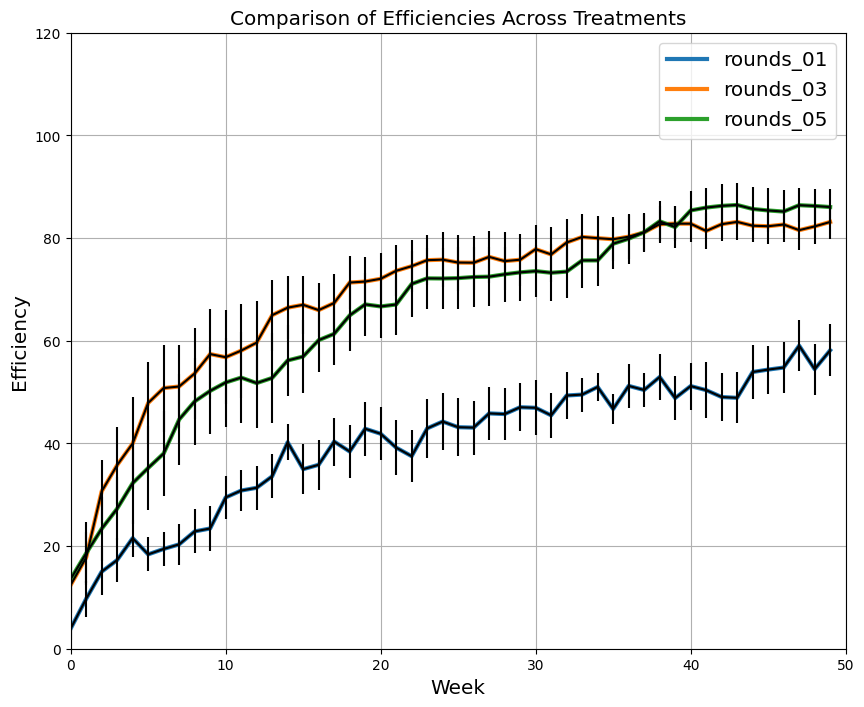

In [42]:
exp_eff, exp_class, exp_group = dm_utils.summary_surplus(exp_df)
dm_utils.plot_comp_efficiencies(exp_eff)

#### Handling Simulation Inputs with Dictionaries

The above function also makes of another functionality of dm_sim.make_monte_carlo(\*) - by passing passed_as_dict=True and params_dict=in_vars, we can use make_monte_carlo(\*) with the dictionary instead of having to unwrap the inputs ourselves.

An example of this behavior is demonstrated below. Note we override the value of num_rounds in sim_vars - this is also how the make_experiment(\*) function overrides the inputs to correspond to the treatment.

In [44]:
in_vars_2 = sim_vars.copy() # Here we make a shallow copy - appropriate when changing only an integer - however if we wanted to change values within agent_groups or group_names you need to use deepcopy() from the copy package
in_vars_2['sim_name'] = 'dict_example'
in_vars_2['num_rounds'] = 3

dict_exam = dm_sim.make_monte_carlo(return_df=True,
                     passed_as_dict=True,
                     params_dict=in_vars_2)
dict_exam.head()

,sim_name,num_weeks,num_periods,num_rounds,num_traders,agent_groups,grid_size,group_names,week,contracts,grids,eff,class_surplus,group_surplus,trial
0,dict_example,50,7,3,10,"[[5, BUYER, ZIDA, {'reset_flag_frequency': 'WI...",15,"[BUYER_ZIDA_gr_0, SELLER_ZIDA_gr_1]",0,[],"[{(7, 6): ['BUYER_0_ZIDA'], (4, 0): ['BUYER_1_...",0.000000,{'ZIDA': 0},"{'BUYER_ZIDA_gr_0': 0, 'SELLER_ZIDA_gr_1': 0}",0
1,dict_example,50,7,3,10,"[[5, BUYER, ZIDA, {'reset_flag_frequency': 'WI...",15,"[BUYER_ZIDA_gr_0, SELLER_ZIDA_gr_1]",1,[],"[{(5, 4): ['BUYER_0_ZIDA'], (3, 3): ['BUYER_1_...",0.000000,{'ZIDA': 0},"{'BUYER_ZIDA_gr_0': 0, 'SELLER_ZIDA_gr_1': 0}",0
2,dict_example,50,7,3,10,"[[5, BUYER, ZIDA, {'reset_flag_frequency': 'WI...",15,"[BUYER_ZIDA_gr_0, SELLER_ZIDA_gr_1]",2,"[(0, 538, BUYER_1_ZIDA, SELLER_6_ZIDA, 0, 578,...","[{(3, 7): ['BUYER_0_ZIDA'], (2, 0): ['SELLER_6...",22.031853,{'ZIDA': 913},"{'BUYER_ZIDA_gr_0': 231, 'SELLER_ZIDA_gr_1': 682}",0
3,dict_example,50,7,3,10,"[[5, BUYER, ZIDA, {'reset_flag_frequency': 'WI...",15,"[BUYER_ZIDA_gr_0, SELLER_ZIDA_gr_1]",3,"[(0, 348, BUYER_1_ZIDA, SELLER_6_ZIDA, 0, 578,...","[{(4, 2): ['BUYER_0_ZIDA'], (2, 0): ['SELLER_6...",44.063707,{'ZIDA': 1826},"{'BUYER_ZIDA_gr_0': 886, 'SELLER_ZIDA_gr_1': 940}",0
4,dict_example,50,7,3,10,"[[5, BUYER, ZIDA, {'reset_flag_frequency': 'WI...",15,"[BUYER_ZIDA_gr_0, SELLER_ZIDA_gr_1]",4,"[(1, 453, BUYER_1_ZIDA, SELLER_6_ZIDA, 0, 578,...","[{(5, 2): ['BUYER_0_ZIDA'], (2, 0): ['BUYER_1_...",44.498069,{'ZIDA': 1844},"{'BUYER_ZIDA_gr_0': 1027, 'SELLER_ZIDA_gr_1': ...",0


## Data Analysis

Show the Data Analysis 

## Visualizing Agent Movement

## Equilibrium Determination



# Example Experiment: Comparing Agent Strategies

A key determinant in the outcomes of the simulations, as shown above, are the strategies employed by agents. Our first detailed experiment therefore compares the results of agents following each of the defined strategies 

## Experimental Configuration



# Intervention Event Experiments

A particularly interesting experiment one can conduct with this simulation is to change something within the 

# Conducted Experiments and Further Reading

If you wish to read about experiments we have conducted in this environment, including configuration, calibration, results, and analysis, we have documented these results in the following notebooks:

# TODO Fix notebooks to work with new code
# TODO Document notebooks


# Technical Information

If you encountered any problems executing the above code, there may be a number of reasons for this, however a common issue arises from packages and dependencies not playing well together. For this reason, I include below the technical specs of my python configuration for which the code executes as expected.

Python Version


Package Versions
